In [73]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   # graphical
from sklearn.preprocessing import scale
import sklearn.linear_model as lm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [77]:
df = pd.read_csv(r"C:\Users\Aarav\Downloads\insurance.csv",na_values="?").dropna()

In [87]:
ad = pd.read_csv(r"C:\Users\Aarav\Downloads\insurance.csv",na_values="?").dropna()

In [78]:
df

,age,Gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [79]:
df.columns

Index(['age', 'Gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [80]:
df = pd.get_dummies(df)

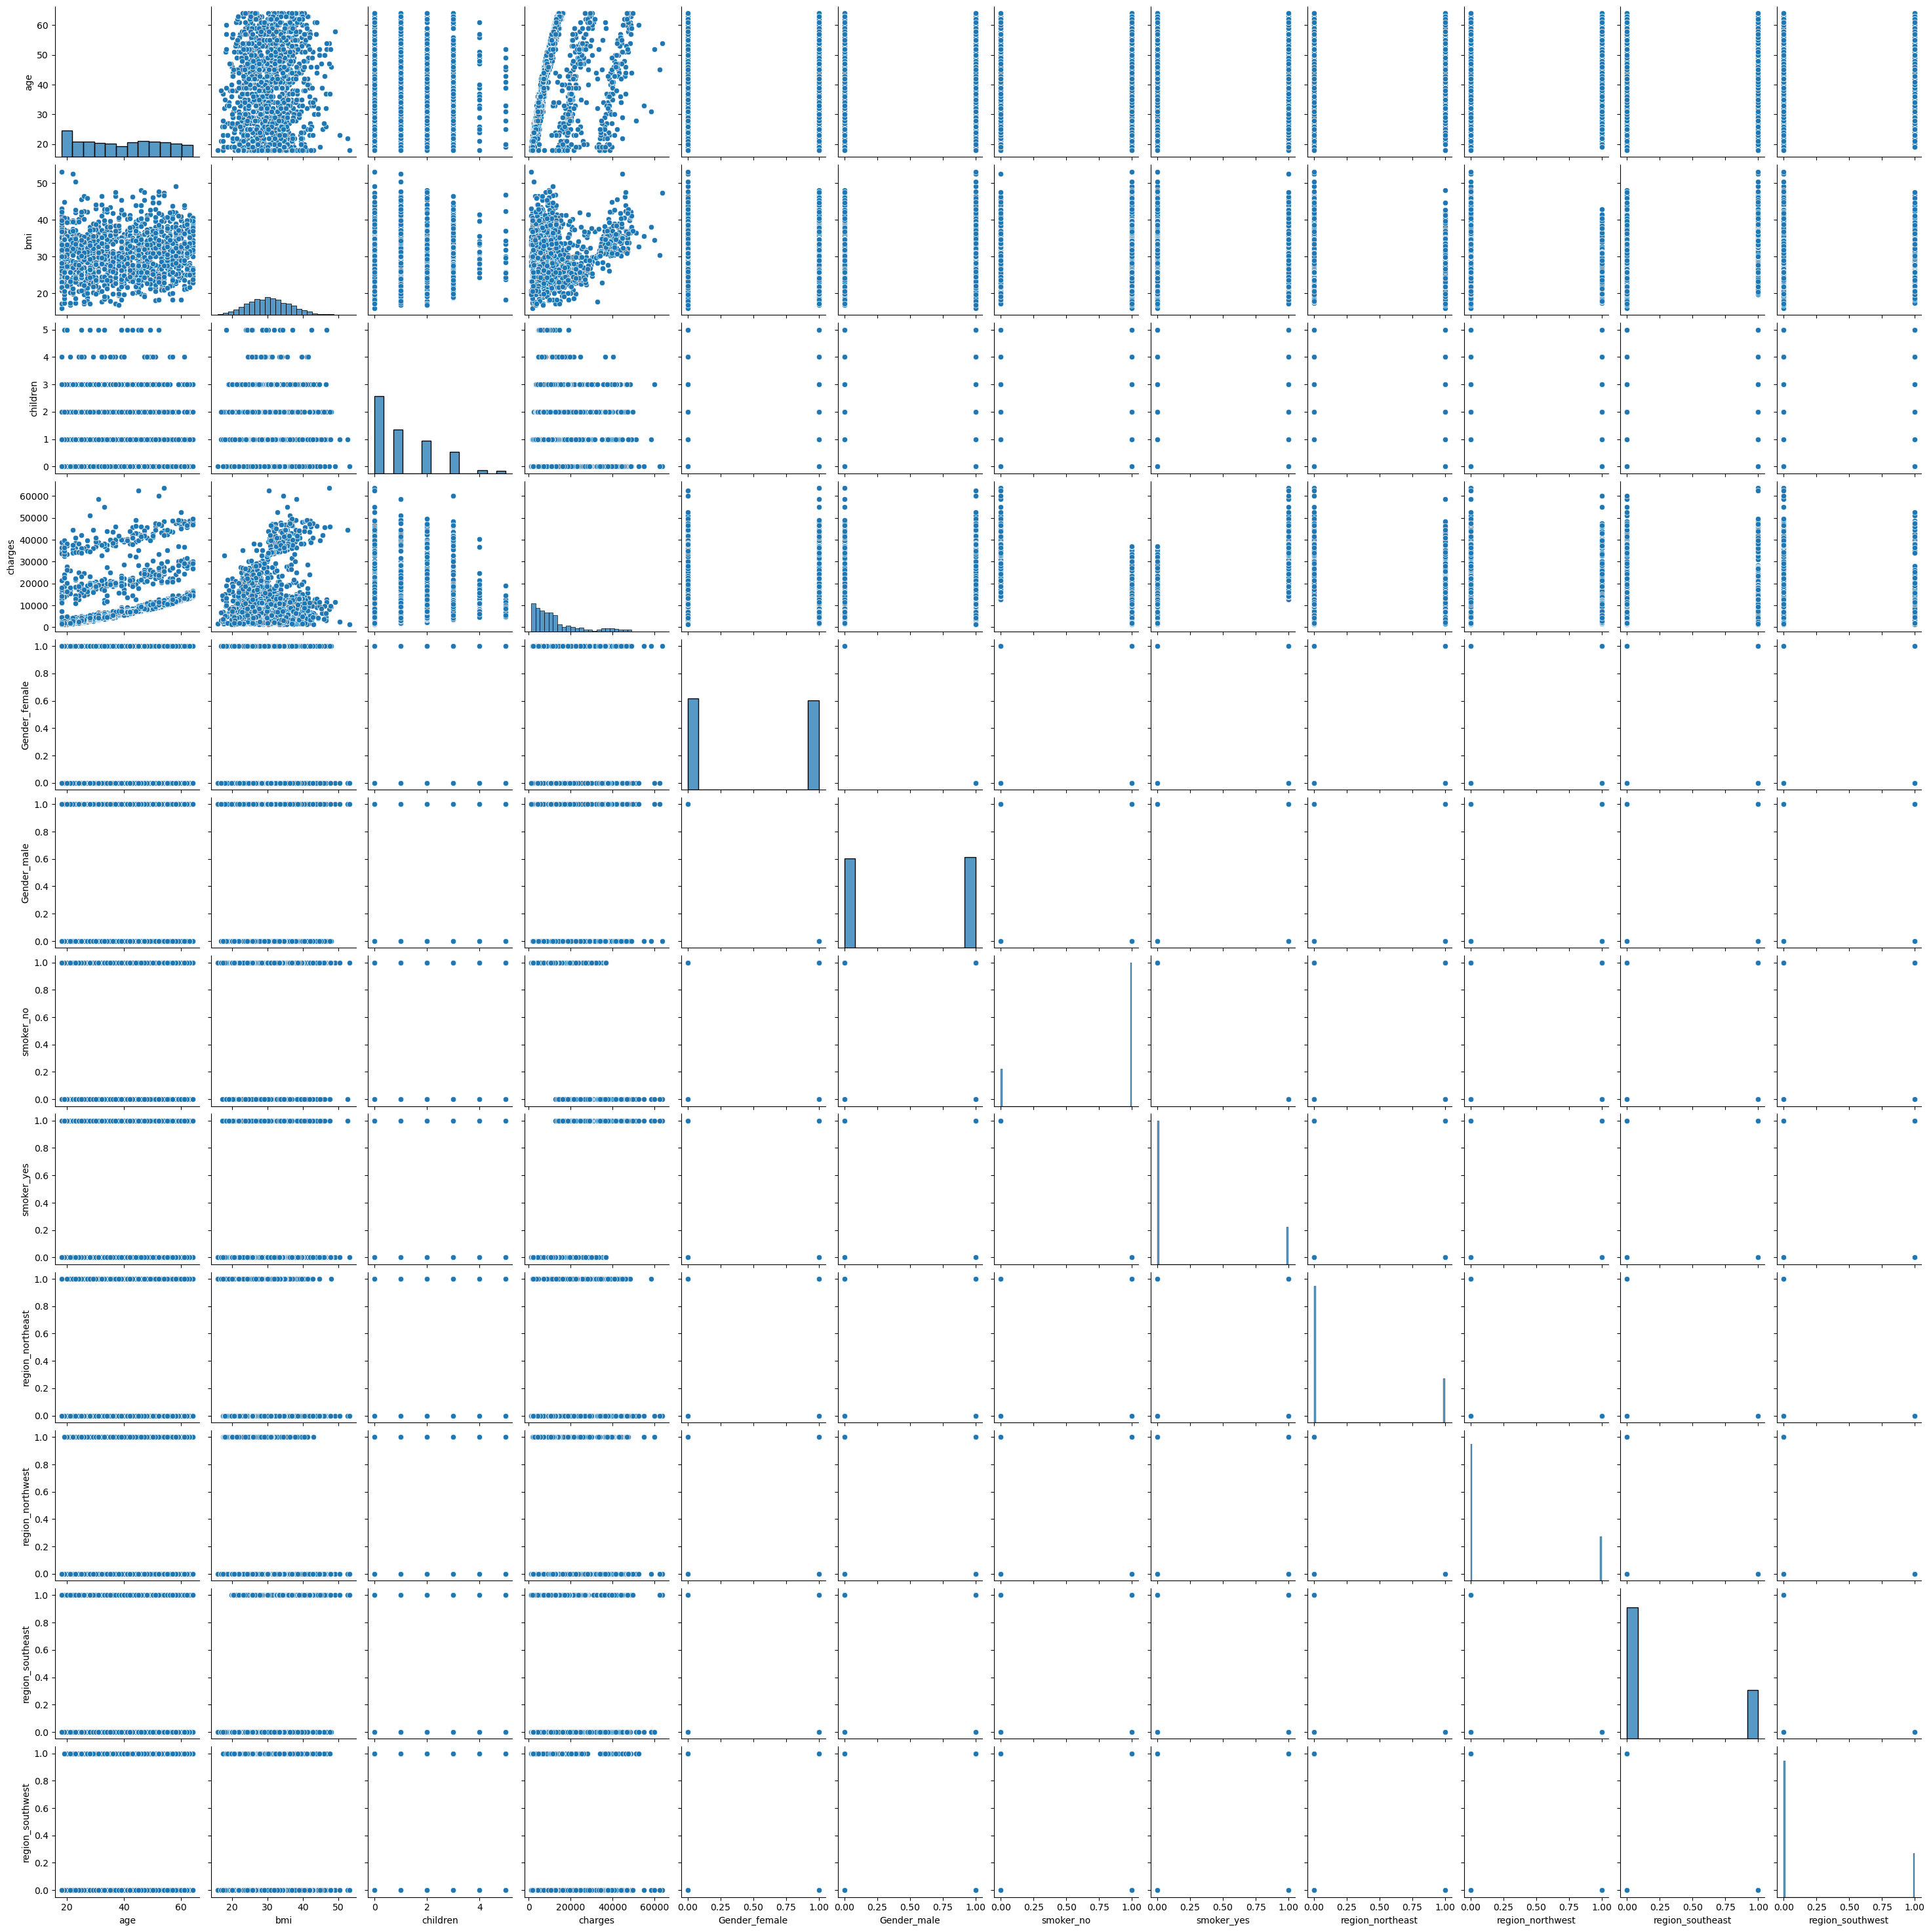

In [81]:
sns.pairplot(df[['age', 'bmi', 'children', 'charges', 'Gender_female', 'Gender_male',
       'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest']])

In [82]:
lm_fit1 = smf.ols("bmi~ age + charges +region_southeast+region_southwest",df).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    bmi   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     44.51
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           4.07e-35
Time:                        13:05:53   Log-Likelihood:                -4233.3
No. Observations:                1338   AIC:                             8477.
Df Residuals:                    1333   BIC:                             8503.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   27.0565      0.494     54.769      0.000      26.087      28.026
region_southeast[T.True]     4.0285      0.377     10.699      0.000       3.290       4.767
region_southwest[T.True]     1.4499      0.390      3.719      0.000       0.685       2.215
age                          0.0274      0.012      2.343      0.019       0.004       0.050
charges                   8.162e-05   1.36e-05      5.991      0.000    5.49e-05       0.000
==============================================================================
Omnibus:                       11.701   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               11.939
Skew:                           0.228   Prob(JB):                      0.00256
Kurtosis:                       2.924   Cond. No.                     6.23e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.23e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [83]:
annova4=sm.stats.anova_lm(lm_fit1,typ=1)
annova4

,df,sum_sq,mean_sq,F,PR(>F)
region_southeast,1.0,3625.264438,3625.264438,110.175913,8.076239e-25
region_southwest,1.0,430.504125,430.504125,13.083510,3.090320e-04
age,1.0,621.817270,621.817270,18.897735,1.483993e-05
charges,1.0,1181.144574,1181.144574,35.896328,2.673516e-09
Residual,1333.0,43861.469979,32.904329,NaN,NaN


In [84]:
lm_fit2 = smf.ols("bmi~Gender_female + Gender_male + smoker_no + smoker_yes + region_northeast + region_northwest + region_southeast + region_southwest",df).fit()
lm_fit2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    bmi   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     24.22
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           2.15e-23
Time:                        13:05:53   Log-Likelihood:                -4258.9
No. Observations:                1338   AIC:                             8530.
Df Residuals:                    1332   BIC:                             8561.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                 8.078e+12   3.91e+13      0.207      0.836   -6.87e+13    8.48e+13
Gender_female[T.True]    -4.605e+12   2.23e+13     -0.207      0.836   -4.83e+13    3.91e+13
Gender_male[T.True]      -4.605e+12   2.23e+13     -0.207      0.836   -4.83e+13    3.91e+13
smoker_no[T.True]        -5.356e+12   2.59e+13     -0.207      0.836   -5.62e+13    4.55e+13
smoker_yes[T.True]       -5.356e+12   2.59e+13     -0.207      0.836   -5.62e+13    4.55e+13
region_northeast[T.True]  1.883e+12   9.12e+12      0.207      0.836    -1.6e+13    1.98e+13
region_northwest[T.True]  1.883e+12   9.12e+12      0.207      0.836    -1.6e+13    1.98e+13
region_southeast[T.True]  1.883e+12   9.12e+12      0.207      0.836    -1.6e+13    1.98e+13
region_southwest[T.True]  1.883e+12   9.12e+12      0.207      0.836    -1.6e+13    1.98e+13
==============================================================================
Omnibus:                        9.871   Durbin-Watson:                   2.067
Prob(Omnibus):                  0.007   Jarque-Bera (JB):                9.718
Skew:                           0.185   Prob(JB):                      0.00776
Kurtosis:                       2.807   Cond. No.                     2.75e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.34e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [85]:
vfib  = 1 / (1 - 0.083)
print(vfib)

1.0905125408942202


In [117]:
X = df[['Gender_female', 'Gender_male','smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest','region_southeast', 'region_southwest']]
X = add_constant(X)
X = X.astype(float)
vif_ab = pd.DataFrame()
vif_ab ["Feature"] = X.columns

vif_ab ["VIF"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]

print(vif_ab)

            Feature           VIF
0             const  0.000000e+00
1     Gender_female  8.594314e+02
2       Gender_male  1.972567e+04
3         smoker_no  1.240018e+04
4        smoker_yes  9.291107e+03
5  region_northeast  6.387938e+06
6  region_northwest  1.151446e+04
7  region_southeast  3.851325e+05
8  region_southwest  2.951895e+02


C:\Users\Aarav\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [89]:
ad.columns

Index(['age', 'Gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [100]:
lm_fit1 = smf.ols("bmi~ C(region) + C(Gender) + C(smoker)",ad).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    bmi   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     24.30
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.83e-23
Time:                        13:14:40   Log-Likelihood:                -4258.7
No. Observations:                1338   AIC:                             8529.
Df Residuals:                    1332   BIC:                             8561.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 28.9628      0.369     78.418      0.000      28.238      29.687
C(region)[T.northwest]     0.0232      0.459      0.050      0.960      -0.878       0.924
C(region)[T.southeast]     4.1850      0.447      9.361      0.000       3.308       5.062
C(region)[T.southwest]     1.4168      0.459      3.085      0.002       0.516       2.318
C(Gender)[T.male]          0.5224      0.321      1.629      0.104      -0.107       1.152
C(smoker)[T.yes]          -0.2522      0.398     -0.633      0.527      -1.034       0.529
==============================================================================
Omnibus:                        9.889   Durbin-Watson:                   2.066
Prob(Omnibus):                  0.007   Jarque-Bera (JB):                9.747
Skew:                           0.186   Prob(JB):                      0.00765
Kurtosis:                       2.809   Cond. No.                         5.57
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [98]:
lm_fit1 = smf.ols("bmi~ region_southeast+region_southwest",df).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    bmi   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     59.29
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           2.15e-25
Time:                        13:14:11   Log-Likelihood:                -4260.2
No. Observations:                1338   AIC:                             8526.
Df Residuals:                    1335   BIC:                             8542.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   29.1867      0.230    127.133      0.000      28.736      29.637
region_southeast[T.True]     4.1693      0.383     10.886      0.000       3.418       4.921
region_southwest[T.True]     1.4100      0.397      3.548      0.000       0.630       2.190
==============================================================================
Omnibus:                        9.713   Durbin-Watson:                   2.066
Prob(Omnibus):                  0.008   Jarque-Bera (JB):                9.518
Skew:                           0.181   Prob(JB):                      0.00857
Kurtosis:                       2.802   Cond. No.                         3.25
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

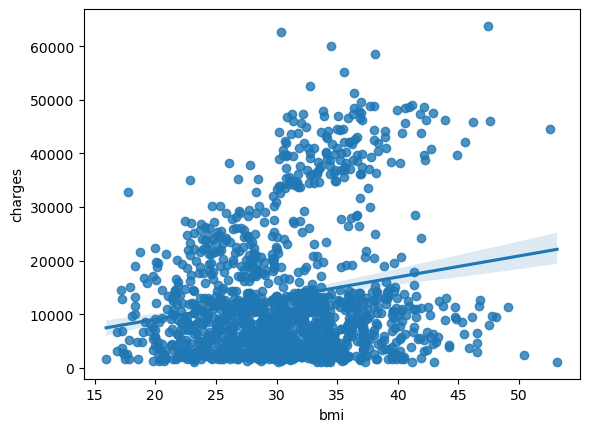

In [118]:
sns.regplot(data=df,x="bmi",y="charges",order=1)
plt.show()

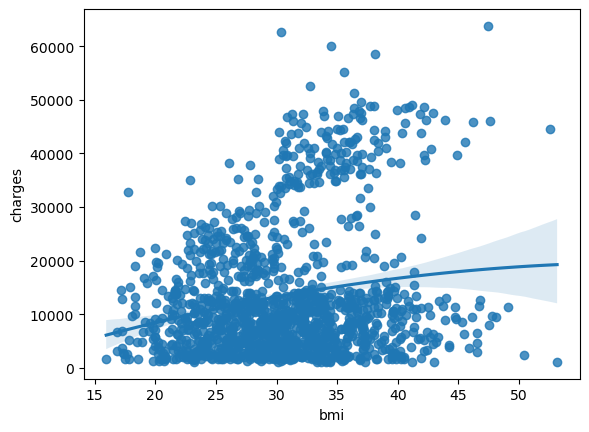

In [119]:
sns.regplot(data=df,x="bmi",y="charges",order=2)
plt.show()

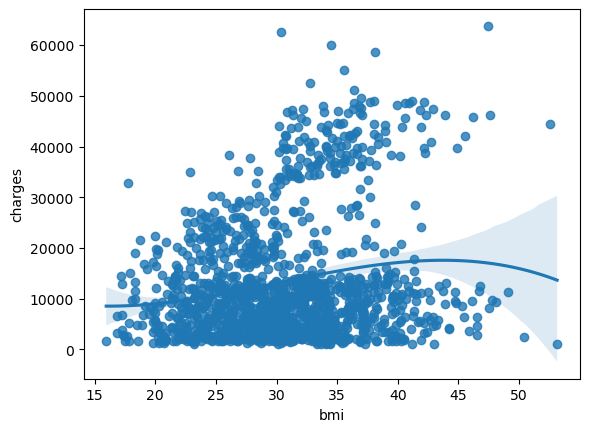

In [120]:
sns.regplot(data=df,x="bmi",y="charges",order=3)
plt.show()

In [121]:
lm_fit1 = smf.ols("charges~ bmi",df).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.71
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           2.46e-13
Time:                        14:23:13   Log-Likelihood:                -14451.
No. Observations:                1338   AIC:                         2.891e+04
Df Residuals:                    1336   BIC:                         2.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1192.9372   1664.802      0.717      0.474   -2072.974    4458.849
bmi          393.8730     53.251      7.397      0.000     289.409     498.337
==============================================================================
Omnibus:                      261.030   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              431.091
Skew:                           1.297   Prob(JB):                     2.45e-94
Kurtosis:                       4.004   Cond. No.                         160.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [122]:
df["bmi2"] = df["bmi"].values ** 2

In [123]:
lm_fit1 = smf.ols("charges~ bmi2",df).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     51.68
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.08e-12
Time:                        14:24:11   Log-Likelihood:                -14452.
No. Observations:                1338   AIC:                         2.891e+04
Df Residuals:                    1336   BIC:                         2.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7381.2891    881.307      8.375      0.000    5652.394    9110.185
bmi2           6.0253      0.838      7.189      0.000       4.381       7.670
==============================================================================
Omnibus:                      263.309   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              437.060
Skew:                           1.302   Prob(JB):                     1.24e-95
Kurtosis:                       4.029   Cond. No.                     2.85e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.85e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [125]:
lm_fit1 = smf.ols("charges~ C(Gender)",ad).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     4.400
Date:                Mon, 06 Apr 2026   Prob (F-statistic):             0.0361
Time:                        14:29:15   Log-Likelihood:                -14475.
No. Observations:                1338   AIC:                         2.895e+04
Df Residuals:                    1336   BIC:                         2.897e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          1.257e+04    470.072     26.740      0.000    1.16e+04    1.35e+04
C(Gender)[T.male]  1387.1723    661.331      2.098      0.036      89.812    2684.532
==============================================================================
Omnibus:                      331.451   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              636.534
Skew:                           1.496   Prob(JB):                    6.00e-139
Kurtosis:                       4.572   Cond. No.                         2.63
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [126]:
df.columns

Index(['age', 'bmi', 'children', 'charges', 'Gender_female', 'Gender_male',
       'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest', 'bmi2'],
      dtype='object')

In [128]:
lm_fit1 = smf.ols("charges~ Gender_male",df).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     4.400
Date:                Mon, 06 Apr 2026   Prob (F-statistic):             0.0361
Time:                        14:30:10   Log-Likelihood:                -14475.
No. Observations:                1338   AIC:                         2.895e+04
Df Residuals:                    1336   BIC:                         2.897e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.257e+04    470.072     26.740      0.000    1.16e+04    1.35e+04
Gender_male[T.True]  1387.1723    661.331      2.098      0.036      89.812    2684.532
==============================================================================
Omnibus:                      331.451   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              636.534
Skew:                           1.496   Prob(JB):                    6.00e-139
Kurtosis:                       4.572   Cond. No.                         2.63
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [129]:
lm_fit1 = smf.ols("charges~ Gender_female",df).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     4.400
Date:                Mon, 06 Apr 2026   Prob (F-statistic):             0.0361
Time:                        14:30:32   Log-Likelihood:                -14475.
No. Observations:                1338   AIC:                         2.895e+04
Df Residuals:                    1336   BIC:                         2.897e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              1.396e+04    465.179     30.003      0.000     1.3e+04    1.49e+04
Gender_female[T.True] -1387.1723    661.331     -2.098      0.036   -2684.532     -89.812
==============================================================================
Omnibus:                      331.451   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              636.534
Skew:                           1.496   Prob(JB):                    6.00e-139
Kurtosis:                       4.572   Cond. No.                         2.61
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [132]:
lm_fit1 = smf.ols("charges~ bmi + Gender_male",df).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     29.01
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           4.63e-13
Time:                        14:32:09   Log-Likelihood:                -14449.
No. Observations:                1338   AIC:                         2.890e+04
Df Residuals:                    1335   BIC:                         2.892e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             739.4306   1682.451      0.439      0.660   -2561.105    4039.966
Gender_male[T.True]  1166.9940    649.416      1.797      0.073    -106.994    2440.982
bmi                   389.4347     53.264      7.311      0.000     284.945     493.924
==============================================================================
Omnibus:                      257.470   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              422.431
Skew:                           1.284   Prob(JB):                     1.86e-92
Kurtosis:                       3.990   Cond. No.                         163.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [134]:
lm_fit1 = smf.ols("charges~ bmi + Gender_female",df).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     29.01
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           4.63e-13
Time:                        14:34:06   Log-Likelihood:                -14449.
No. Observations:                1338   AIC:                         2.890e+04
Df Residuals:                    1335   BIC:                         2.892e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              1906.4246   1710.145      1.115      0.265   -1448.440    5261.289
Gender_female[T.True] -1166.9940    649.416     -1.797      0.073   -2440.982     106.994
bmi                     389.4347     53.264      7.311      0.000     284.945     493.924
==============================================================================
Omnibus:                      257.470   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              422.431
Skew:                           1.284   Prob(JB):                     1.86e-92
Kurtosis:                       3.990   Cond. No.                         166.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""